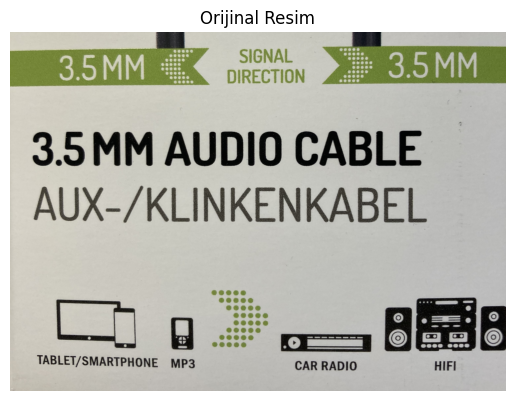

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


img = cv2.imread(r"C:\Users\Onur\openCV_IMG_process\colorRegionApp\CableLabelRGB.bmp")


img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


plt.imshow(img_rgb)
plt.title("Orijinal Resim")
plt.axis('off')
plt.show()

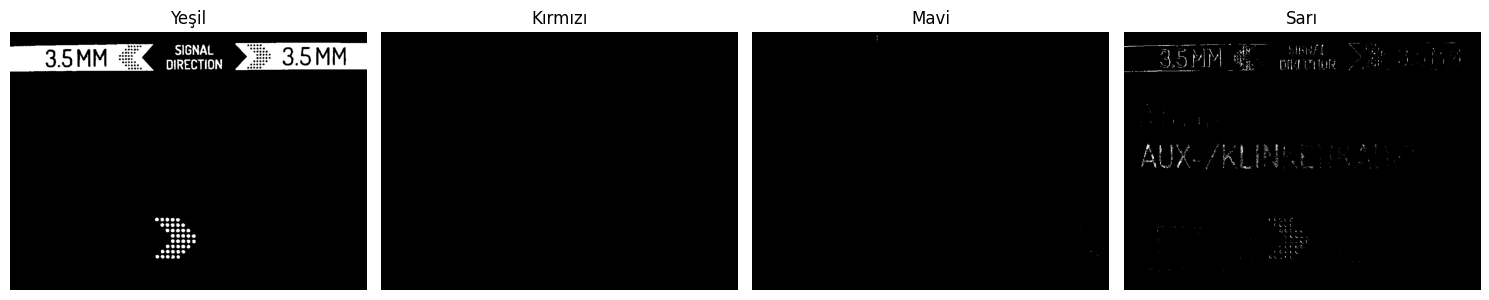

In [14]:
# HSV'ye çevir
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Renk aralıklarını tanımla (HSV)
renkler = {
    "Yeşil": ([35, 50, 50], [85, 255, 255]),
    "Kırmızı": ([0, 50, 50], [10, 255, 255]),
    "Mavi": ([100, 50, 50], [130, 255, 255]),
    "Sarı": ([20, 50, 50], [35, 255, 255]),
}

fig, axes = plt.subplots(1, len(renkler), figsize=(15, 5))

for ax, (renk_adi, (alt, ust)) in zip(axes, renkler.items()):
    alt = np.array(alt)
    ust = np.array(ust)
    mask = cv2.inRange(img_hsv, alt, ust)
    ax.imshow(mask, cmap='gray')
    ax.set_title(renk_adi)
    ax.axis('off')

plt.tight_layout()
plt.show()

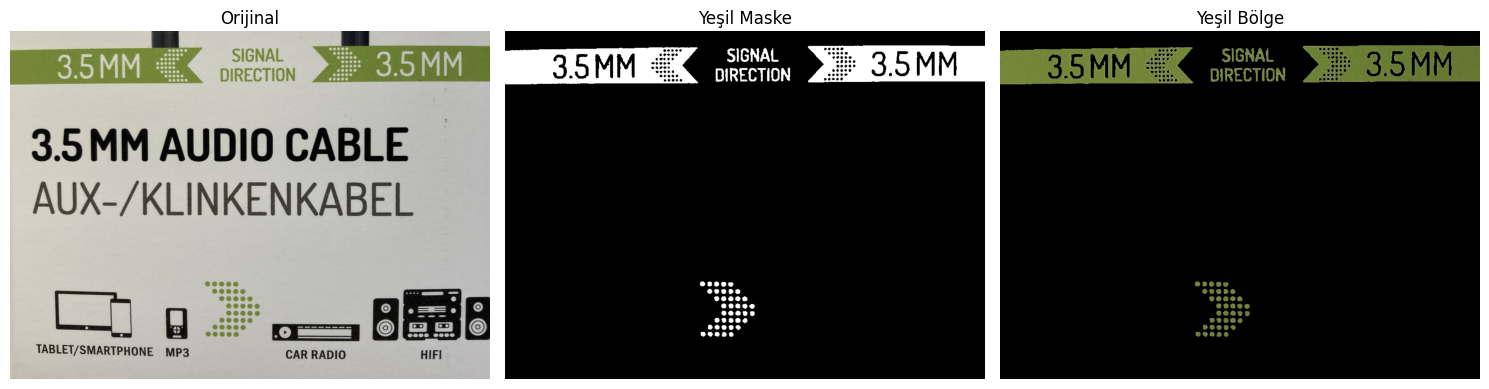

In [15]:
# Yeşil maske oluştur
alt_yesil = np.array([35, 50, 50])
ust_yesil = np.array([85, 255, 255])
mask_yesil = cv2.inRange(img_hsv, alt_yesil, ust_yesil)

# Maskeyi orijinal resme uygula (color region)
yesil_bolge = cv2.bitwise_and(img, img, mask=mask_yesil)
yesil_bolge_rgb = cv2.cvtColor(yesil_bolge, cv2.COLOR_BGR2RGB)

# Göster
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("Orijinal")
axes[0].axis('off')

axes[1].imshow(mask_yesil, cmap='gray')
axes[1].set_title("Yeşil Maske")
axes[1].axis('off')

axes[2].imshow(yesil_bolge_rgb)
axes[2].set_title("Yeşil Bölge")
axes[2].axis('off')

plt.tight_layout()
plt.show()

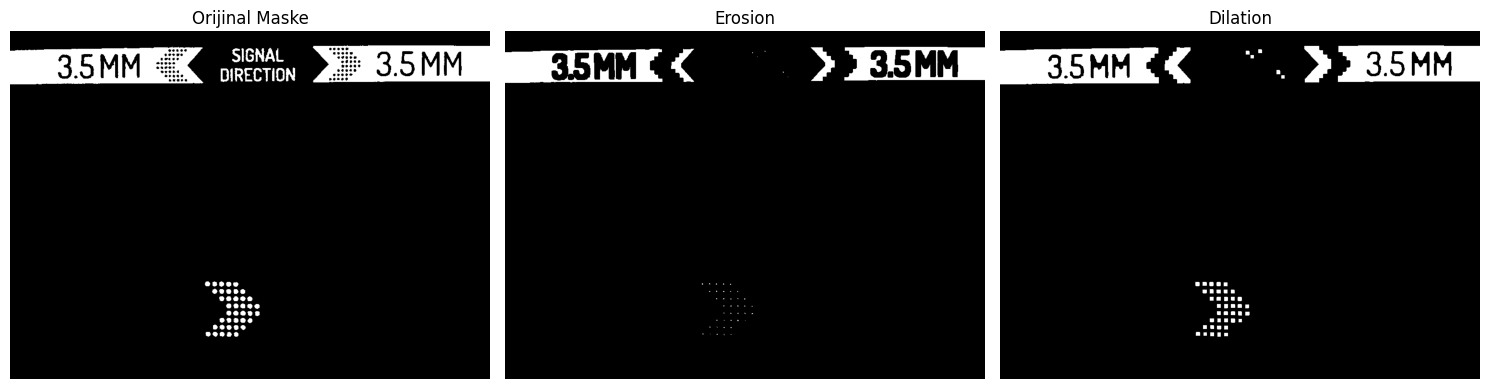

In [16]:
# 7x7 kernel (for erosion and dilation)
kernel = np.ones((7, 7), np.uint8)

# Erosion - gürültüyü temizle
erosion = cv2.erode(mask_yesil, kernel, iterations=1)

# Dilation - şekli geri düzelt
dilation = cv2.dilate(erosion, kernel, iterations=1)

# Göster
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(mask_yesil, cmap='gray')
axes[0].set_title("Orijinal Maske")
axes[0].axis('off')

axes[1].imshow(erosion, cmap='gray')
axes[1].set_title("Erosion")
axes[1].axis('off')

axes[2].imshow(dilation, cmap='gray')
axes[2].set_title("Dilation")
axes[2].axis('off')

plt.tight_layout()
plt.show()